# Netflix Movies & TV Shows — Exploratory Data Analysis
**Author:**  Marvis Obanor
**Date:**  16 June 2026
**Dataset:**  Netflix Titles (Kaggle)

## Introduction
Netflix is one of the world's largest streaming platforms with thousands 
of titles spanning multiple countries and genres. In this project, I 
perform an exploratory data analysis (EDA) on the Netflix content library 
to answer the following questions:

- What is the split between Movies and TV Shows?
- Which countries produce the most content?
- What are the most popular genres?
- How has Netflix's content library grown over the years?
- What audience does Netflix primarily target based on content ratings?

The dataset was sourced from Kaggle and contains Netflix titles added 
to the platform up until 2021.

In [24]:
# Import libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn's plot style for cleaner and more professional charts
sns.set_style("whitegrid")


# Set the default size for all plots
plt.rcParams["figure.figsize"] = (10, 5)

In [25]:
# Loading  dataset from a CSV file into a Pandas DataFrame
df = pd.read_csv(r"C:\Users\HP\Downloads\PORTFOLIO PROJECT\netflix_titles\netflix_titles.csv")

In [26]:
# Checking how many rows and columns
print(df.shape)

(8807, 12)


In [27]:
# First 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
# Identify and count missing values in each column
# This helps determine which columns may need cleaning or preprocessing
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [29]:
# Drop rows where important columns are missing
df.dropna(subset=["type", "title", "country", "listed_in", "rating"], inplace=True)


In [30]:
# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

In [31]:
# Extract year added
df["year_added"] = df["date_added"].dt.year

In [32]:
# Check how many rows remain
print(df.shape)

(7973, 13)


# What is the split between Movies and TV Shows on Netflix ?

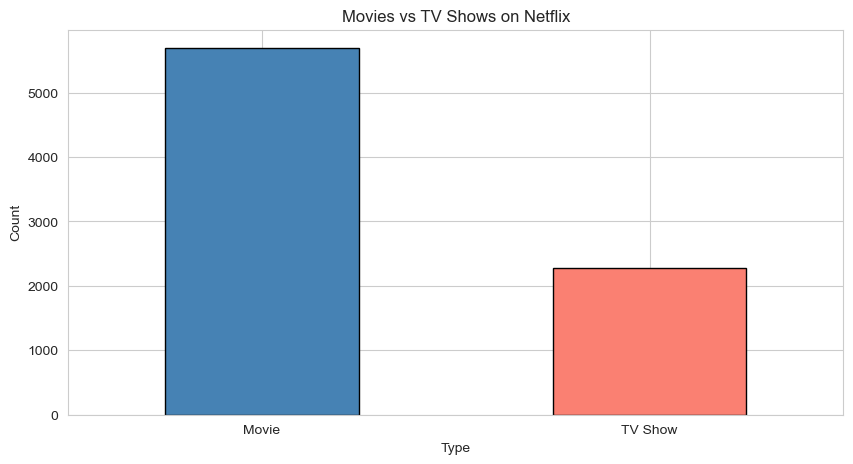

In [33]:
# Count the number of Movies and TV Shows
type_counts = df["type"].value_counts()

# Plot as a bar chart to visually compare the two categories
type_counts.plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)  # Keep labels horizontal for readability
plt.show()

MOVIES VS TV SHOWS

Netflix's content library is heavily skewed toward Movies, which make up roughly 70% of all titles compared to about 30% for TV Shows. This suggests Netflix initially built its platform around film content before expanding its original TV series offerings. As a user, this means you're more likely to find a movie than a series when browsing the platform.

# Which countries produce the most content on Netflix ?

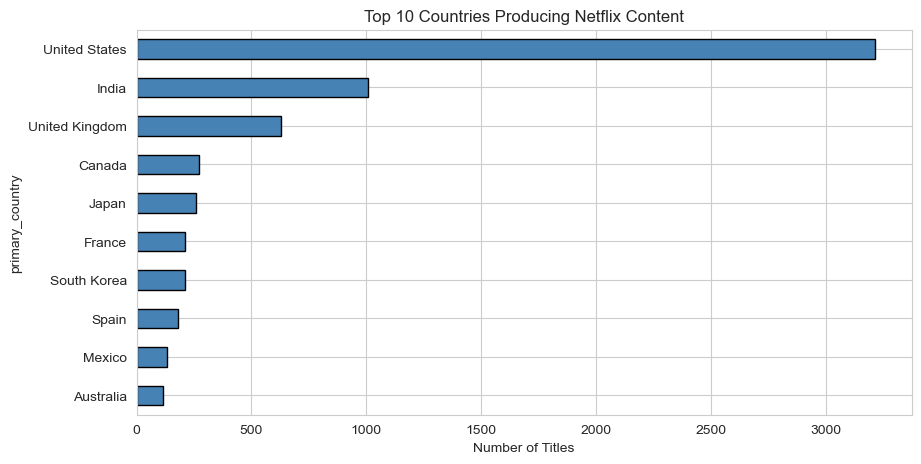

In [34]:
# Some titles list multiple countries, so we extract only the first/primary one
df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip())

# Get the top 10 countries by number of titles
top_countries = df["primary_country"].value_counts().head(10)

# Use a horizontal bar chart since country names are long
top_countries.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()  # Show the highest value at the top
plt.show()

TOP 10 COUNTRIES

The United States dominates Netflix's content production by a significant margin, followed by India and the United Kingdom. This reflects both Hollywood's global influence and Netflix's strategic investment in Bollywood content to capture the massive Indian streaming market. Notably, the top 3 countries alone account for a large portion of all content on the platform.

# What are the most popular genres on Netflix ?

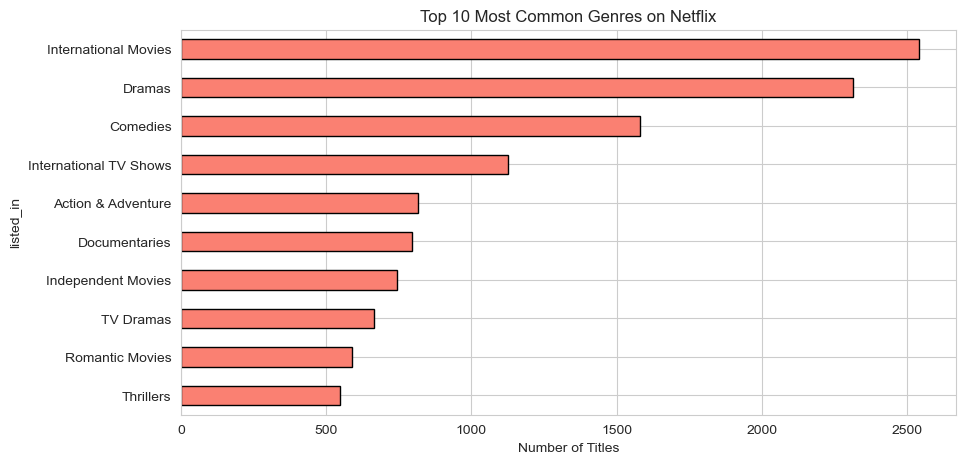

In [35]:
# Each title can belong to multiple genres separated by commas
# Split and explode so each genre gets its own row
genres = df["listed_in"].str.split(",").explode().str.strip()

# Get the top 10 most frequent genres
top_genres = genres.value_counts().head(10)

top_genres.plot(kind="barh", color="salmon", edgecolor="black")
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()  # Show the highest value at the top
plt.show()

MOST COMMON GENRES

International Movies and Dramas are the most represented genres on Netflix, suggesting the platform caters heavily to global audiences beyond just English-speaking markets. Comedies and Documentaries also rank highly, indicating Netflix targets a broad range of viewer moods and preferences. The dominance of International content is particularly interesting as it reflects Netflix's push toward global expansion.


# How has Netflix's content library grown over the years ?

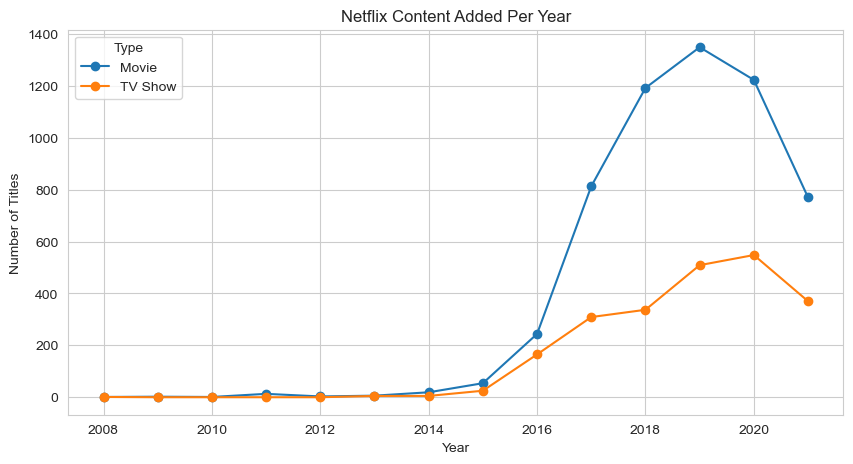

In [36]:
# Group by year and type to see how each category grew over time
yearly = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
# fill_value=0 replaces missing years with 0 instead of NaN

# Line chart works best for showing trends over time
yearly.plot(kind="line", marker="o")
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

CONTENT GROWTH OVER THE YEARS

Netflix experienced explosive content growth between 2015 and 2019, with the number of titles added each year rising sharply during this period. Growth appears to plateau or dip slightly around 2020–2021, likely due to production slowdowns caused by the COVID-19 pandemic. This trend shows how aggressively Netflix scaled its library during its peak expansion phase.

# What type of audience does Netflix primarily target based on content ratings?

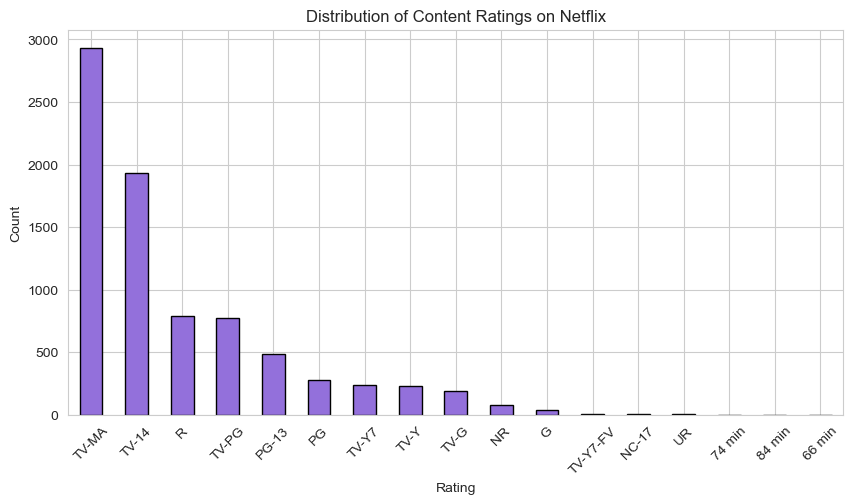

In [37]:
# Count how many titles fall under each rating category
rating_counts = df["rating"].value_counts()

rating_counts.plot(kind="bar", color="mediumpurple", edgecolor="black")
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate labels so they don't overlap
plt.show()

CONTENT RATINGS DISTRIBUTION

TV-MA is by far the most common rating on Netflix, meaning a large portion of content is intended for mature audiences aged 17 and above. TV-14 and TV-PG follow behind, while family-friendly ratings like G and PG are comparatively rare. This suggests Netflix's primary target demographic leans toward adult viewers rather than children or families.

In [38]:
# Final summary of key insights from the analysis
print("=== PROJECT SUMMARY ===")
print(f"Total Titles Analyzed: {df.shape[0]}")  # shape[0] returns the number of rows
print(f"Movies: {type_counts.get('Movie', 0)}")  # .get() returns 0 if 'Movie' is not found
print(f"TV Shows: {type_counts.get('TV Show', 0)}")
print(f"Top Country: {top_countries.index[0]}")  # index[0] picks the highest ranked value
print(f"Top Genre: {top_genres.index[0]}")

=== PROJECT SUMMARY ===
Total Titles Analyzed: 7973
Movies: 5690
TV Shows: 2283
Top Country: United States
Top Genre: International Movies
